In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Exercise 1 - House Buying Decision Tree

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
data = {
    'Age': [25, 35, 45, 20, 55, 32, 40, 28, 50, 38,
            22, 60, 33, 48, 27, 52, 30, 42, 18, 65],
    'Income': [30000, 60000, 80000, 20000, 90000, 50000, 70000, 35000, 85000, 65000,
               25000, 95000, 55000, 75000, 28000, 88000, 40000, 72000, 18000, 92000],
    'BuysHouse': [0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
                  0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}
df = pd.DataFrame(data)
print(df)

    Age  Income  BuysHouse
0    25   30000          0
1    35   60000          1
2    45   80000          1
3    20   20000          0
4    55   90000          1
5    32   50000          0
6    40   70000          1
7    28   35000          0
8    50   85000          1
9    38   65000          1
10   22   25000          0
11   60   95000          1
12   33   55000          0
13   48   75000          1
14   27   28000          0
15   52   88000          1
16   30   40000          0
17   42   72000          1
18   18   18000          0
19   65   92000          1


In [ ]:
print(df.isnull().sum())
print(df.shape)

Age          0
Income       0
BuysHouse    0
dtype: int64
(20, 3)


In [ ]:
print(f"People over 30 who bought house: {df[df['Age'] > 30]['BuysHouse'].mean():.0%}")

People over 30 who bought house: 85%


In [ ]:
x = df[['Age', 'Income']]
y = df['BuysHouse']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(16, 2) (4, 2)


In [ ]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("Predicted:", y_pred)
print("Actual:   ", y_test.values)

Predicted: [0 1 1 0]
Actual:    [0 1 1 1]


In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Accuracy %:", int(metrics.accuracy_score(y_test, y_pred)*100), '%')
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred))

Confusion Matrix:
 [[1 0]
 [1 2]]
Accuracy: 0.75
Accuracy %: 75 %

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



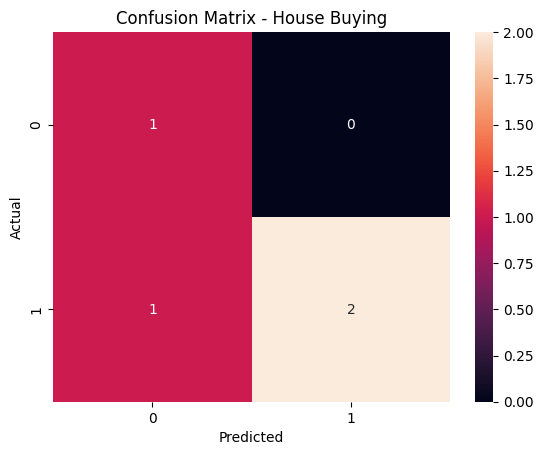

In [ ]:
sn.heatmap(conf_mat, annot=True, fmt='d')
plt.title('Confusion Matrix - House Buying')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

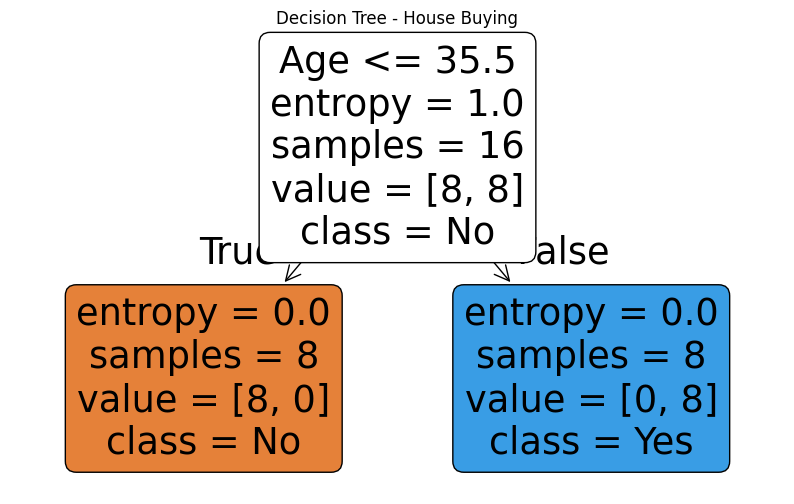

In [ ]:
plt.figure(figsize=(10, 6))
plot_tree(model, feature_names=['Age', 'Income'],
          class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title('Decision Tree - House Buying')
plt.show()

In [ ]:
print("Observation: Age is the root node (primary split).")
print("People over 30 with higher income are more likely to buy a house.")
print("Income is the secondary decision factor.")

Observation: Age is the root node (primary split).
People over 30 with higher income are more likely to buy a house.
Income is the secondary decision factor.
